# Torch o'Chess - Comprehensive Debug & Experimentation Notebook

This notebook provides a complete walkthrough of all functionalities in the
torch-OChess project, including:

1. **Data Encoding** - FEN parsing, move encoding, score encoding
2. **Data Generation** - Stockfish analysis, position generation
3. **Dataset Loading** - PyTorch datasets and dataloaders
4. **Model Architectures** - ResNet, Transformer, Hybrid
5. **Loss Functions** - Multi-task learning losses
6. **Training** - Training loop, callbacks, metrics
7. **Evaluation & Inference** - Playing against Stockfish

## Prerequisites
- Stockfish installed and accessible
- torch-OChess package installed (`pip install -e .`)

---
# Section 1: Setup & Configuration
---

In [1]:
# Configuration flags - Set these to control notebook behavior
RUN_TRAINING = False  # Set to True to run actual training (takes time)
RUN_LONG_OPERATIONS = False  # Set to True for time-consuming operations
RUN_STOCKFISH_EVAL = False  # Set to True to run Stockfish evaluation matches

# Stockfish path - UPDATE THIS FOR YOUR SYSTEM
STOCKFISH_PATH = "/usr/local/bin/stockfish"

In [2]:
# Standard library imports
import sys
import os
from pathlib import Path
from dataclasses import asdict
import json
import time

# Add project root to path
PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Third-party imports
import torch
import torch.nn as nn
import numpy as np
import chess

# Check for optional visualization library
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print("matplotlib not installed - some visualizations will be skipped")

In [3]:
# Device configuration
def get_device():
    """Get the best available device."""
    if torch.cuda.is_available():
        device = "cuda"
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
        print("Using Apple Metal (MPS)")
    else:
        device = "cpu"
        print("Using CPU")
    return device

# DEVICE = get_device()
DEVICE = 'cpu' # NOTE: On MPS Conv3d is not available ...
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch version: 2.2.2
Device: cpu


In [4]:
# Project paths
DATASETS_DIR = PROJECT_ROOT / "datasets"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
CACHE_DIR = DATASETS_DIR / "cache"

print(f"Project root: {PROJECT_ROOT}")
print(f"Datasets dir: {DATASETS_DIR}")
print(f"Checkpoints dir: {CHECKPOINTS_DIR}")

# Create directories if they don't exist
DATASETS_DIR.mkdir(exist_ok=True)
CHECKPOINTS_DIR.mkdir(exist_ok=True)

Project root: /opt/SP/Workspace/Python/torch-OChess
Datasets dir: /opt/SP/Workspace/Python/torch-OChess/datasets
Checkpoints dir: /opt/SP/Workspace/Python/torch-OChess/checkpoints


---
# Section 2: Data Encoding Deep Dive
---

Understanding how chess positions and moves are encoded is fundamental to the project.

## 2.1 FenParser - Board Representation

The `FenParser` converts FEN strings to PyTorch tensors and back.

**Piece Encoding:**
- 0: empty square
- 1-6: White pieces (P, N, B, R, Q, K)
- 7-12: Black pieces (p, n, b, r, q, k)

In [5]:
from ochess.data.fen_parser import FenParser

fen_parser = FenParser()

# Show the piece encoding mappings
print("Piece to Index mapping:")
for piece, idx in sorted(FenParser.PIECE_TO_INDEX.items(), key=lambda x: x[1]):
    print(f"  '{piece}' -> {idx}")

Piece to Index mapping:
  ' ' -> 0
  'P' -> 1
  'N' -> 2
  'B' -> 3
  'R' -> 4
  'Q' -> 5
  'K' -> 6
  'p' -> 7
  'n' -> 8
  'b' -> 9
  'r' -> 10
  'q' -> 11
  'k' -> 12


In [6]:
# Convert a starting position FEN to tensor
starting_fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"
board_tensor = fen_parser.to_tensor(starting_fen)

print(f"Input FEN: {starting_fen}")
print(f"Output tensor shape: {board_tensor.shape}")
print(f"Tensor dtype: {board_tensor.dtype}")
print(f"\nBoard tensor (8x8):")
print(board_tensor)

Input FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Output tensor shape: torch.Size([8, 8])
Tensor dtype: torch.int64

Board tensor (8x8):
tensor([[10,  8,  9, 11, 12,  9,  8, 10],
        [ 7,  7,  7,  7,  7,  7,  7,  7],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  1,  1,  1,  1,  1,  1,  1],
        [ 4,  2,  3,  5,  6,  3,  2,  4]])


In [7]:
# Visualize the board using the display method
print("Board visualization (ASCII):")
print(fen_parser.display(board_tensor, use_unicode=False))

print("\nBoard visualization (Unicode):")
print(fen_parser.display(board_tensor, use_unicode=True))

Board visualization (ASCII):
   a b c d e f g h
  +-+-+-+-+-+-+-+-+
8 |r|n|b|q|k|b|n|r|
  +-+-+-+-+-+-+-+-+
7 |p|p|p|p|p|p|p|p|
  +-+-+-+-+-+-+-+-+
6 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
5 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
4 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
3 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
2 |P|P|P|P|P|P|P|P|
  +-+-+-+-+-+-+-+-+
1 |R|N|B|Q|K|B|N|R|
  +-+-+-+-+-+-+-+-+
   a b c d e f g h

Board visualization (Unicode):
   a b c d e f g h
  +-+-+-+-+-+-+-+-+
8 |♜|♞|♝|♛|♚|♝|♞|♜|
  +-+-+-+-+-+-+-+-+
7 |♟|♟|♟|♟|♟|♟|♟|♟|
  +-+-+-+-+-+-+-+-+
6 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
5 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
4 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
3 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
2 |♙|♙|♙|♙|♙|♙|♙|♙|
  +-+-+-+-+-+-+-+-+
1 |♖|♘|♗|♕|♔|♗|♘|♖|
  +-+-+-+-+-+-+-+-+
   a b c d e f g h


In [8]:
# One-hot encoding (13 channels for 13 piece types including empty)
onehot_tensor = fen_parser.to_tensor_onehot(starting_fen)
print(f"One-hot tensor shape: {onehot_tensor.shape}")
print(f"One-hot dtype: {onehot_tensor.dtype}")

# Show which channel is active for a specific square (e8 = black king)
# Row 0, Col 4 should have channel 12 (black king) active
print(f"\nSquare e8 (black king) channels: {onehot_tensor[0, 4, :]}")
print(f"Active channel: {onehot_tensor[0, 4, :].argmax().item()} (should be 12)")

One-hot tensor shape: torch.Size([8, 8, 13])
One-hot dtype: torch.float32

Square e8 (black king) channels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
Active channel: 12 (should be 12)


In [9]:
# Round-trip conversion: FEN -> tensor -> FEN
reconstructed_fen = fen_parser.to_fen(board_tensor)
print(f"Original FEN:      {starting_fen}")
print(f"Reconstructed FEN: {reconstructed_fen}")
print(f"Match: {starting_fen.split()[0] == reconstructed_fen}")

Original FEN:      rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
Reconstructed FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR
Match: True


In [10]:
# Board normalization for Black's perspective
# When Black is to move, we flip the board and swap colors
# This way the network always sees the position from the current player's view

test_fen = "r1bqkbnr/pppppppp/2n5/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 1 2"
test_tensor = fen_parser.to_tensor(test_fen)
white_to_move = fen_parser.is_white_to_move(test_fen)

print(f"Position: {test_fen}")
print(f"White to move: {white_to_move}")

print("\nOriginal board (from White's view):")
print(fen_parser.display(test_tensor, use_unicode=True))

# Normalize for Black's perspective
normalized = fen_parser.normalize_for_player(test_tensor, white_to_move=False)
print("\nNormalized board (from Black's view - flipped and colors swapped):")
print(fen_parser.display(normalized, use_unicode=True))

Position: r1bqkbnr/pppppppp/2n5/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 1 2
White to move: False

Original board (from White's view):
   a b c d e f g h
  +-+-+-+-+-+-+-+-+
8 |♜|.|♝|♛|♚|♝|♞|♜|
  +-+-+-+-+-+-+-+-+
7 |♟|♟|♟|♟|♟|♟|♟|♟|
  +-+-+-+-+-+-+-+-+
6 |.|.|♞|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
5 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
4 |.|.|.|.|♙|.|.|.|
  +-+-+-+-+-+-+-+-+
3 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
2 |♙|♙|♙|♙|.|♙|♙|♙|
  +-+-+-+-+-+-+-+-+
1 |♖|♘|♗|♕|♔|♗|♘|♖|
  +-+-+-+-+-+-+-+-+
   a b c d e f g h

Normalized board (from Black's view - flipped and colors swapped):
   a b c d e f g h
  +-+-+-+-+-+-+-+-+
8 |♜|♞|♝|♚|♛|♝|♞|♜|
  +-+-+-+-+-+-+-+-+
7 |♟|♟|♟|.|♟|♟|♟|♟|
  +-+-+-+-+-+-+-+-+
6 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
5 |.|.|.|♟|.|.|.|.|
  +-+-+-+-+-+-+-+-+
4 |.|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
3 |.|.|.|.|.|♘|.|.|
  +-+-+-+-+-+-+-+-+
2 |♙|♙|♙|♙|♙|♙|♙|♙|
  +-+-+-+-+-+-+-+-+
1 |♖|♘|♗|♔|♕|♗|.|♖|
  +-+-+-+-+-+-+-+-+
   a b c d e f g h


In [11]:
# FEN validation
valid_fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"
invalid_fen = "rnbqkbnr/pppppppp/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"  # Missing row

is_valid, error = fen_parser.validate_fen(valid_fen)
print(f"Valid FEN: {is_valid}, Error: {error}")

is_valid, error = fen_parser.validate_fen(invalid_fen)
print(f"Invalid FEN: {is_valid}, Error: {error}")

Valid FEN: True, Error: None
Invalid FEN: False, Error: expected 8 rows in position part of fen: 'rnbqkbnr/pppppppp/8/8/8/PPPPPPPP/RNBQKBNR'


## 2.2 MoveEncoder - Move Representation

Moves are encoded as indices 0-4095 using the formula:
```
index = from_square * 64 + to_square
```

Square numbering follows python-chess convention:
- a1=0, b1=1, ..., h1=7
- a2=8, b2=9, ..., h2=15
- ...
- a8=56, b8=57, ..., h8=63

In [12]:
from ochess.data.move_encoder import MoveEncoder

move_encoder = MoveEncoder()

print(f"Number of possible move indices: {MoveEncoder.NUM_MOVES}")
print(f"Number of squares: {MoveEncoder.NUM_SQUARES}")

Number of possible move indices: 4096
Number of squares: 64


In [13]:
# Encode and decode moves
test_moves = ["e2e4", "d7d5", "g1f3", "b8c6", "e1g1"]  # Including castling

for uci_move in test_moves:
    index = move_encoder.encode(uci_move)
    decoded = move_encoder.decode(index)
    from_sq, to_sq = move_encoder.get_from_to_squares(index)
    print(f"{uci_move} -> index {index:4d} -> {decoded} (from sq {from_sq}, to sq {to_sq})")

e2e4 -> index  796 -> e2e4 (from sq 12, to sq 28)
d7d5 -> index 3299 -> d7d5 (from sq 51, to sq 35)
g1f3 -> index  405 -> g1f3 (from sq 6, to sq 21)
b8c6 -> index 3690 -> b8c6 (from sq 57, to sq 42)
e1g1 -> index  262 -> e1g1 (from sq 4, to sq 6)


In [14]:
# Working with python-chess Move objects
board = chess.Board()
move = chess.Move.from_uci("e2e4")

index = move_encoder.encode_move(move)
decoded_move = move_encoder.decode_to_move(index, board)

print(f"Original move: {move}")
print(f"Encoded index: {index}")
print(f"Decoded move: {decoded_move}")
print(f"Match: {move == decoded_move}")

Original move: e2e4
Encoded index: 796
Decoded move: e2e4
Match: True


In [15]:
# Get legal move mask for a position
board = chess.Board()
legal_mask = move_encoder.get_legal_move_mask(board)

print(f"Legal move mask shape: {legal_mask.shape}")
print(f"Number of legal moves: {legal_mask.sum().item()}")
print(f"Actual legal moves: {len(list(board.legal_moves))}")

# Show some legal move indices
legal_indices = torch.where(legal_mask)[0][:10]
print(f"\nFirst 10 legal move indices and their UCI:")
for idx in legal_indices:
    print(f"  {idx.item():4d} -> {move_encoder.decode(idx.item())}")

Legal move mask shape: torch.Size([4096])
Number of legal moves: 20
Actual legal moves: 20

First 10 legal move indices and their UCI:
    80 -> b1a3
    82 -> b1c3
   405 -> g1f3
   407 -> g1h3
   528 -> a2a3
   536 -> a2a4
   593 -> b2b3
   601 -> b2b4
   658 -> c2c3
   666 -> c2c4


In [16]:
# Filter logits to only legal moves
random_logits = torch.randn(4096)
filtered_logits = move_encoder.filter_to_legal(random_logits, board)

print(f"Original logits range: [{random_logits.min():.2f}, {random_logits.max():.2f}]")
print(f"Illegal move logits are set to: {filtered_logits[~legal_mask][0].item()}")

# Get the best legal move
best_idx = filtered_logits.argmax().item()
print(f"\nBest legal move: {move_encoder.decode(best_idx)}")

Original logits range: [-4.06, 3.27]
Illegal move logits are set to: -inf

Best legal move: a2a4


In [17]:
# Move normalization for Black's perspective
# When the board is flipped for Black, moves need to be normalized too

move_idx = move_encoder.encode("e2e4")  # White's e2-e4
normalized_idx = move_encoder.normalize_move_for_black(move_idx)
denormalized_idx = move_encoder.denormalize_move_for_black(normalized_idx)

print(f"Original: e2e4 (index {move_idx})")
print(f"Normalized for Black: {move_encoder.decode(normalized_idx)} (index {normalized_idx})")
print(f"Denormalized: {move_encoder.decode(denormalized_idx)} (index {denormalized_idx})")

Original: e2e4 (index 796)
Normalized for Black: d7d5 (index 3299)
Denormalized: e2e4 (index 796)


## 2.3 ScoreEncoder - The Critical Fix

**This is the most important encoding!**

The original code used `abs(score)` which lost perspective information,
causing the network to only play effectively as Black.

**The Fix:** Scores are always encoded from the **side-to-move perspective**:
- Positive score = Good for the player whose turn it is
- Negative score = Bad for the player whose turn it is

In [18]:
from ochess.data.score_encoder import ScoreEncoder

score_encoder = ScoreEncoder(normalize=True, scale=1000.0)

In [19]:
# Demonstrate the perspective encoding
# Stockfish always reports from White's perspective
# +150 means White is better by 1.5 pawns

stockfish_score = "+150"  # White is better

# When it's White's turn: +150 is GOOD (positive for me)
white_encoded = score_encoder.encode(stockfish_score, white_to_move=True)

# When it's Black's turn: +150 is BAD (negative for me)
black_encoded = score_encoder.encode(stockfish_score, white_to_move=False)

print("Score perspective encoding demonstration:")
print(f"Stockfish says: {stockfish_score} (White is better by 1.5 pawns)")
print(f"")
print(f"White to move: encoded as {white_encoded:+.3f} (good for me)")
print(f"Black to move: encoded as {black_encoded:+.3f} (bad for me)")

Score perspective encoding demonstration:
Stockfish says: +150 (White is better by 1.5 pawns)

White to move: encoded as +0.150 (good for me)
Black to move: encoded as -0.150 (bad for me)


In [20]:
# More examples to drive the point home
test_cases = [
    ("+300", True, "White is much better, White's turn"),
    ("+300", False, "White is much better, Black's turn"),
    ("-200", True, "Black is better, White's turn"),
    ("-200", False, "Black is better, Black's turn"),
    ("#5", True, "White mates in 5, White's turn"),
    ("#-3", False, "Black mates in 3, Black's turn"),
]

print("Comprehensive score encoding examples:")
print("-" * 60)
for score_str, white_to_move, description in test_cases:
    encoded = score_encoder.encode(score_str, white_to_move)
    turn = "White" if white_to_move else "Black"
    print(f"{description}")
    print(f"  Raw: {score_str}, Turn: {turn}, Encoded: {encoded:+.3f}")
    print()

Comprehensive score encoding examples:
------------------------------------------------------------
White is much better, White's turn
  Raw: +300, Turn: White, Encoded: +0.300

White is much better, Black's turn
  Raw: +300, Turn: Black, Encoded: -0.300

Black is better, White's turn
  Raw: -200, Turn: White, Encoded: -0.200

Black is better, Black's turn
  Raw: -200, Turn: Black, Encoded: +0.200

White mates in 5, White's turn
  Raw: #5, Turn: White, Encoded: +9.500

Black mates in 3, Black's turn
  Raw: #-3, Turn: Black, Encoded: +9.700



In [21]:
# Why abs(score) was broken - demonstration
print("WHY abs(score) WAS BROKEN:")
print("-" * 40)
print("Old code: encoded = abs(centipawns) / 1000")
print()
print("Position: White is winning by +300 cp")
print()
print("OLD (broken):")
print(f"  White to move: abs(+300)/1000 = +0.300 (looks good)")
print(f"  Black to move: abs(+300)/1000 = +0.300 (WRONG! Should be bad)")
print()
print("NEW (fixed):")
white_enc = score_encoder.encode("+300", white_to_move=True)
black_enc = score_encoder.encode("+300", white_to_move=False)
print(f"  White to move: {white_enc:+.3f} (good for me)")
print(f"  Black to move: {black_enc:+.3f} (bad for me)")

WHY abs(score) WAS BROKEN:
----------------------------------------
Old code: encoded = abs(centipawns) / 1000

Position: White is winning by +300 cp

OLD (broken):
  White to move: abs(+300)/1000 = +0.300 (looks good)
  Black to move: abs(+300)/1000 = +0.300 (WRONG! Should be bad)

NEW (fixed):
  White to move: +0.300 (good for me)
  Black to move: -0.300 (bad for me)


In [22]:
# Score to win probability conversion
# Uses sigmoid: P(win) = 1 / (1 + exp(-cp/300))

test_scores = [-1000, -500, -300, -100, 0, 100, 300, 500, 1000]

print("Score to Win Probability conversion:")
print("-" * 40)
for cp in test_scores:
    encoded = cp / 1000.0  # Already normalized
    win_prob = score_encoder.score_to_win_probability(encoded)
    print(f"  {cp:+5d} cp -> {win_prob:.1%} win probability")

Score to Win Probability conversion:
----------------------------------------
  -1000 cp -> 3.4% win probability
   -500 cp -> 15.9% win probability
   -300 cp -> 26.9% win probability
   -100 cp -> 41.7% win probability
     +0 cp -> 50.0% win probability
   +100 cp -> 58.3% win probability
   +300 cp -> 73.1% win probability
   +500 cp -> 84.1% win probability
  +1000 cp -> 96.6% win probability


In [23]:
# Human-readable score interpretation
test_scores_for_explanation = [0, 50, 150, 300, 500, 1000, 9900]

print("Score interpretation:")
print("-" * 40)
for cp in test_scores_for_explanation:
    explanation = score_encoder.explain_score(cp)
    print(f"  {cp:5d} cp: {explanation}")

Score interpretation:
----------------------------------------
      0 cp: Equal position
     50 cp: White has slight advantage (+0.5 pawns)
    150 cp: White has slight advantage (+1.5 pawns)
    300 cp: White has clear advantage (+3.0 pawns)
    500 cp: White is winning (+5.0 pawns)
   1000 cp: White is winning (+10.0 pawns)
   9900 cp: White has forced mate


---
# Section 3: Data Generation
---

Generate training data using Stockfish analysis.

## 3.1 StockfishWrapper

Wrapper around the Stockfish chess engine for position analysis.

In [24]:
from ochess.datagen.stockfish_wrapper import StockfishWrapper

# Check if Stockfish exists
if not Path(STOCKFISH_PATH).exists():
    print(f"WARNING: Stockfish not found at {STOCKFISH_PATH}")
    print("Please update STOCKFISH_PATH at the top of this notebook")
    STOCKFISH_AVAILABLE = False
else:
    print(f"Stockfish found at {STOCKFISH_PATH}")
    STOCKFISH_AVAILABLE = True

Stockfish found at /usr/local/bin/stockfish


In [25]:
# Initialize and use Stockfish (if available)
if STOCKFISH_AVAILABLE:
    # Using context manager for automatic cleanup
    with StockfishWrapper(
        stockfish_path=STOCKFISH_PATH,
        threads=4,
        hash_mb=256,
        skill_level=20  # Maximum strength
    ) as engine:
        print("Stockfish engine started successfully")
        print(f"Running: {engine.is_running()}")

        # Analyze starting position
        board = chess.Board()
        results = engine.analyze(board, depth=15, multipv=3)

        print(f"\nAnalysis of starting position (depth 15):")
        for i, result in enumerate(results, 1):
            print(f"  PV {i}: {result.best_move} (score: {result.score_str})")

Stockfish engine started successfully
Running: True

Analysis of starting position (depth 15):
  PV 1: e2e4 (score: +31)
  PV 2: d2d4 (score: +28)
  PV 3: g1f3 (score: +23)


In [26]:
# More analysis examples
if STOCKFISH_AVAILABLE:
    with StockfishWrapper(STOCKFISH_PATH) as engine:
        # Analyze a tactical position
        tactical_fen = "r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4"
        board = chess.Board(tactical_fen)

        print(f"Position: {tactical_fen}")
        print(f"(Scholar's Mate threat)")
        print()

        # Get best move
        best_move, score = engine.get_best_move(board, depth=15)
        print(f"Best move: {best_move} (score: {score} cp)")

        # Get top 5 moves
        print("\nTop 5 moves:")
        top_moves = engine.get_top_moves(board, n=5, depth=15)
        for move, mv_score in top_moves:
            san = board.san(move)
            print(f"  {san:8s} ({move.uci()}): {mv_score:+5d} cp")

Position: r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4
(Scholar's Mate threat)

Best move: h5f7 (score: 9900 cp)

Top 5 moves:
  Qxf7#    (h5f7): +9900 cp
  Qd1      (h5d1):  -166 cp
  Qh4      (h5h4):  -179 cp
  Qe2      (h5e2):  -188 cp
  Qf3      (h5f3):  -191 cp


In [27]:
# Evaluate a specific move
if STOCKFISH_AVAILABLE:
    with StockfishWrapper(STOCKFISH_PATH) as engine:
        board = chess.Board()

        # Evaluate e2e4 vs a2a3
        e4_score = engine.evaluate_move(board, chess.Move.from_uci("e2e4"), depth=15)
        a3_score = engine.evaluate_move(board, chess.Move.from_uci("a2a3"), depth=15)

        print(f"Move evaluation comparison:")
        print(f"  1.e4: {e4_score:+d} cp")
        print(f"  1.a3: {a3_score:+d} cp")
        print(f"  Difference: {e4_score - a3_score} cp in favor of e4")

Move evaluation comparison:
  1.e4: -43 cp
  1.a3: +8 cp
  Difference: -51 cp in favor of e4


## 3.2 PositionGenerator

Generate diverse chess positions for training data.

In [28]:
from ochess.datagen.position_generator import PositionGenerator, PositionType

# Initialize with seed for reproducibility
pos_generator = PositionGenerator(seed=42)

In [29]:
# Generate positions from random games
print("Generating positions from random games:")
random_positions = list(pos_generator.generate_random_game_positions(
    num_positions=10,
    max_game_length=100,
    skip_first_n=4,  # Skip first 4 moves (too early)
    deduplicate=True
))

for i, pos in enumerate(random_positions[:5]):
    print(f"\n  Position {i+1}:")
    print(f"    FEN: {pos.fen[:50]}...")
    print(f"    Type: {pos.position_type.value}")
    print(f"    Move: {pos.move_number}")
    print(f"    Source: {pos.source}")

Generating positions from random games:

  Position 1:
    FEN: 1rbqkbnr/pppppppp/n7/8/8/3P4/PPPKPPPP/RNBQ1BNR w k...
    Type: opening
    Move: 4
    Source: random_game

  Position 2:
    FEN: 1rbqkbnr/pppppppp/n7/8/8/3PK3/PPP1PPPP/RNBQ1BNR b ...
    Type: opening
    Move: 5
    Source: random_game

  Position 3:
    FEN: 1rbqkbnr/pp1ppppp/n7/2p5/8/3PK3/PPP1PPPP/RNBQ1BNR ...
    Type: opening
    Move: 6
    Source: random_game

  Position 4:
    FEN: 1rbqkbnr/pp1ppppp/n7/2p5/8/3PK3/PPPBPPPP/RN1Q1BNR ...
    Type: opening
    Move: 7
    Source: random_game

  Position 5:
    FEN: r1bqkbnr/pp1ppppp/n7/2p5/8/3PK3/PPPBPPPP/RN1Q1BNR ...
    Type: opening
    Move: 8
    Source: random_game


In [30]:
# Generate positions from known openings
print("\nGenerating positions from openings:")
pos_generator.clear_dedup_cache()
opening_positions = list(pos_generator.generate_from_openings(
    num_positions=10,
    continuation_depth=20,
    deduplicate=True
))

for i, pos in enumerate(opening_positions[:5]):
    print(f"\n  Position {i+1}:")
    print(f"    FEN: {pos.fen[:50]}...")
    print(f"    Type: {pos.position_type.value}")
    print(f"    Move: {pos.move_number}")
    print(f"    Source: {pos.source}")


Generating positions from openings:

  Position 1:
    FEN: rnbqkbnr/pp2pppp/3p4/8/3NP3/8/PPP2PPP/RNBQKB1R b K...
    Type: opening
    Move: 7
    Source: from_opening

  Position 2:
    FEN: rnbqkbnr/pp2p1pp/3p1p2/8/3NP3/8/PPP2PPP/RNBQKB1R w...
    Type: opening
    Move: 8
    Source: from_opening

  Position 3:
    FEN: rnbqkbnr/pp2p1pp/3p1p2/8/3NP3/3Q4/PPP2PPP/RNB1KB1R...
    Type: opening
    Move: 9
    Source: from_opening

  Position 4:
    FEN: rnbqkbnr/1p2p1pp/3p1p2/p7/3NP3/3Q4/PPP2PPP/RNB1KB1...
    Type: middlegame
    Move: 10
    Source: from_opening

  Position 5:
    FEN: rnbqkbnr/1p2p1pp/3p1p2/p7/3NP2P/3Q4/PPP2PP1/RNB1KB...
    Type: middlegame
    Move: 11
    Source: from_opening


In [31]:
# # Show available openings
# from ochess.datagen.position_generator import COMMON_OPENINGS

# print("Available openings in the generator:")
# for name, moves in COMMON_OPENINGS.items():
#     moves_str = " ".join(moves[:4]) + "..." if len(moves) > 4 else " ".join(moves)
#     print(f"  {name}: {moves_str}")

In [32]:
# Generate endgame positions
print("\nGenerating endgame positions:")
pos_generator.clear_dedup_cache()
endgame_positions = list(pos_generator.generate_endgame_positions(
    num_positions=5,
    max_pieces=8
))

for i, pos in enumerate(endgame_positions):
    board = chess.Board(pos.fen)
    piece_count = len(board.piece_map())
    print(f"\n  Position {i+1}:")
    print(f"    FEN: {pos.fen[:50]}...")
    print(f"    Pieces: {piece_count}")
    print(f"    Type: {pos.position_type.value}")


Generating endgame positions:

  Position 1:
    FEN: 8/3k4/8/1P6/5P1B/1K5N/6PR/8 b - - 0 33...
    Pieces: 8
    Type: endgame

  Position 2:
    FEN: 4k3/8/8/1P6/5P1B/1K5N/6PR/8 w - - 1 34...
    Pieces: 8
    Type: endgame

  Position 3:
    FEN: 4k3/8/8/1P6/5P1B/7N/2K3PR/8 b - - 2 34...
    Pieces: 8
    Type: endgame

  Position 4:
    FEN: 5k2/8/8/1P6/5P1B/7N/2K3PR/8 w - - 3 35...
    Pieces: 8
    Type: endgame

  Position 5:
    FEN: 5k2/8/8/1P6/5P1B/7N/6PR/2K5 b - - 4 35...
    Pieces: 8
    Type: endgame


In [33]:
# Generate mixed positions (recommended for training)
print("\nGenerating mixed positions:")
pos_generator.clear_dedup_cache()
mixed_positions = list(pos_generator.generate_mixed(
    num_positions=10,
    random_ratio=0.5,
    opening_ratio=0.5
))

# Show position type distribution
type_counts = {}
for pos in mixed_positions:
    t = pos.position_type.value
    type_counts[t] = type_counts.get(t, 0) + 1

print("Position type distribution:")
for pos_type, count in sorted(type_counts.items()):
    print(f"  {pos_type}: {count}")


Generating mixed positions:
Position type distribution:
  middlegame: 1
  opening: 9


In [34]:
# Get generation statistics
stats = pos_generator.get_stats()
print("\nGeneration statistics:")
for key, value in stats.items():
    print(f"  {key}: {value}")


Generation statistics:
  unique_positions: 10


## 3.3 DataGenerationPipeline

Full pipeline for generating labeled training datasets.

In [35]:
from ochess.datagen.pipeline import DataGenerationPipeline, LabeledPosition

In [36]:
# Show LabeledPosition structure
print("LabeledPosition fields:")
for field in LabeledPosition.__dataclass_fields__:
    print(f"  - {field}")

LabeledPosition fields:
  - fen
  - white_to_move
  - move_number
  - position_type
  - best_move_uci
  - score_cp
  - score_normalized
  - is_capture
  - is_check
  - is_mate
  - alternative_moves
  - alternative_scores
  - bad_move_uci
  - bad_move_score_cp
  - source
  - game_id


In [37]:
# Create pipeline (if Stockfish available)
if STOCKFISH_AVAILABLE and RUN_LONG_OPERATIONS:
    pipeline = DataGenerationPipeline(
        stockfish_path=STOCKFISH_PATH,
        output_dir=str(DATASETS_DIR),
        analysis_depth=15,  # Lower for faster demo
        stockfish_threads=4,
        stockfish_hash_mb=256,
        include_bad_moves=True,  # For contrastive learning
        multipv=3,  # Analyze top 3 moves
        seed=42
    )

    # Generate a small dataset
    output_path = pipeline.generate_dataset(
        num_positions=100,
        output_name="demo_dataset",
        generation_method="mixed",
        batch_size=20,
        save_intermediate=True
    )

    print(f"Dataset saved to: {output_path}")

    # Also check metadata
    metadata_path = output_path.with_name(output_path.stem + "_metadata.json")
    if metadata_path.exists():
        with open(metadata_path) as f:
            metadata = json.load(f)
        print("\nMetadata:")
        for key, value in metadata.items():
            print(f"  {key}: {value}")
else:
    if not STOCKFISH_AVAILABLE:
        print("Skipping pipeline demo - Stockfish not available")
    else:
        print("Skipping pipeline demo - RUN_LONG_OPERATIONS is False")

Skipping pipeline demo - RUN_LONG_OPERATIONS is False


In [38]:
# Examine existing dataset (if available)
example_dataset = DATASETS_DIR / "example_dataset.parquet"
if example_dataset.exists():
    import pandas as pd

    df = pd.read_parquet(example_dataset)
    print(f"Dataset: {example_dataset.name}")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nSample row:")
    print(df.iloc[0].to_dict())
else:
    print(f"No example dataset found at {example_dataset}")
    print("Generate one using the pipeline above or scripts/generate_data.py")

Dataset: example_dataset.parquet
Shape: (1000, 16)

Columns: ['fen', 'white_to_move', 'move_number', 'position_type', 'best_move_uci', 'score_cp', 'score_normalized', 'is_capture', 'is_check', 'is_mate', 'alternative_moves', 'alternative_scores', 'bad_move_uci', 'bad_move_score_cp', 'source', 'game_id']

Sample row:
{'fen': '1rbqkbnr/pppppppp/n7/8/8/3P4/PPPKPPPP/RNBQ1BNR w k - 3 3', 'white_to_move': True, 'move_number': 4, 'position_type': 'opening', 'best_move_uci': 'd2e1', 'score_cp': -22, 'score_normalized': -0.022, 'is_capture': False, 'is_check': False, 'is_mate': False, 'alternative_moves': '["e2e4", "g1f3"]', 'alternative_scores': '[-60, -69]', 'bad_move_uci': 'b1a3', 'bad_move_score_cp': 75.0, 'source': 'random_game', 'game_id': 'random_1'}


---
# Section 4: Dataset Loading
---

Load datasets and create PyTorch DataLoaders for training.

## 4.1 ChessDataset

In [39]:
from ochess.data.dataset import ChessDataset, create_dataloader, train_val_split

In [40]:
# Check for available datasets
available_datasets = list(DATASETS_DIR.glob("*.parquet"))
print("Available datasets:")
for ds in available_datasets:
    print(f"  - {ds.name}")

Available datasets:
  - train_data_depth_5.parquet
  - mini_dataset.parquet
  - example_dataset.parquet


In [41]:
# Load a dataset (use first available or example)
dataset_path = None
for name in ["mini_dataset.parquet", "example_dataset.parquet", "train_data.parquet"]:
    path = DATASETS_DIR / name
    if path.exists():
        dataset_path = path
        break

if dataset_path:
    print(f"Loading dataset: {dataset_path}")

    dataset = ChessDataset(
        data_path=str(dataset_path),
        sequence_length=5,  # Use 5 consecutive positions
        cache_dir=str(CACHE_DIR),
        use_cache=False
    )

    print(f"Dataset size: {len(dataset)} sequences")

    # Examine a sample
    sample = dataset[0]
    print(f"\nSample keys: {list(sample.keys())}")
    print(f"\nSample shapes:")
    for key, value in sample.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: {value.shape} ({value.dtype})")
        else:
            print(f"  {key}: {value}")
else:
    print("No dataset available. Generate one first using Section 3.")
    dataset = None

Loading dataset: /opt/SP/Workspace/Python/torch-OChess/datasets/mini_dataset.parquet
Dataset size: 452 sequences

Sample keys: ['boards', 'colors', 'target_move', 'score', 'is_capture']

Sample shapes:
  boards: torch.Size([5, 8, 8]) (torch.int64)
  colors: torch.Size([5]) (torch.int64)
  target_move: torch.Size([]) (torch.int64)
  score: torch.Size([]) (torch.float32)
  is_capture: torch.Size([]) (torch.int64)


In [42]:
# Visualize a sample from the dataset
if dataset is not None:
    sample = dataset[0]

    print("Boards in sequence (last position):")
    last_board = sample['boards'][-1]  # Last position in sequence
    print(fen_parser.display(last_board, use_unicode=True))

    print(f"\nTarget move index: {sample['target_move'].item()}")
    print(f"Target move UCI: {move_encoder.decode(sample['target_move'].item())}")
    print(f"Score (normalized): {sample['score'].item():.3f}")
    print(f"Is capture: {sample['is_capture'].item()}")

Boards in sequence (last position):
   a b c d e f g h
  +-+-+-+-+-+-+-+-+
8 |♜|.|♝|♛|♚|.|.|♜|
  +-+-+-+-+-+-+-+-+
7 |.|♟|♟|♟|.|♟|♟|♟|
  +-+-+-+-+-+-+-+-+
6 |♞|.|.|.|♟|♞|.|.|
  +-+-+-+-+-+-+-+-+
5 |♟|.|.|.|.|.|.|.|
  +-+-+-+-+-+-+-+-+
4 |♕|♝|♙|♙|.|.|.|.|
  +-+-+-+-+-+-+-+-+
3 |.|.|♘|.|♙|.|.|.|
  +-+-+-+-+-+-+-+-+
2 |♙|♙|.|.|.|♙|♙|♙|
  +-+-+-+-+-+-+-+-+
1 |♖|.|♗|.|♔|♗|♘|♖|
  +-+-+-+-+-+-+-+-+
   a b c d e f g h

Target move index: 1546
Target move UCI: a4c2
Score (normalized): 0.036
Is capture: 0


## 4.2 DataLoaders

In [43]:
if dataset is not None:
    # Split into train/val
    train_dataset, val_dataset = train_val_split(
        dataset,
        val_ratio=0.1,
        seed=42
    )

    print(f"Train size: {len(train_dataset)}")
    print(f"Val size: {len(val_dataset)}")

    # Create dataloaders
    train_loader = create_dataloader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=0,  # Use 0 for notebook compatibility
        pin_memory=True if DEVICE == "cuda" else False,
        drop_last=True
    )

    val_loader = create_dataloader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=True if DEVICE == "cuda" else False,
        drop_last=False
    )

    print(f"\nTrain batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")

Train size: 407
Val size: 45

Train batches: 12
Val batches: 2


In [44]:
# Iterate through a batch
if dataset is not None:
    batch = next(iter(train_loader))

    print("Batch contents:")
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: {value.shape} ({value.dtype})")

Batch contents:
  boards: torch.Size([32, 5, 8, 8]) (torch.int64)
  colors: torch.Size([32, 5]) (torch.int64)
  target_move: torch.Size([32]) (torch.int64)
  score: torch.Size([32]) (torch.float32)
  is_capture: torch.Size([32]) (torch.int64)


---
# Section 5: Model Architectures
---

Three neural network architectures for chess move prediction.

## 5.1 ChessResNet

AlphaZero-inspired residual network. Fast and efficient.

In [45]:
from ochess.model.chess_resnet import ChessResNet, ChessResNetConfig

# Show all config options
print("ChessResNetConfig parameters:")
default_config = ChessResNetConfig()
for field, value in asdict(default_config).items():
    print(f"  {field}: {value}")

ChessResNetConfig parameters:
  piece_embed_dim: 64
  position_embed_dim: 64
  hidden_dim: 256
  num_residual_blocks: 8
  dropout: 0.3
  num_moves: 4096
  sequence_length: 5
  flip_board_for_black: True


In [46]:
# Create a ResNet model
resnet_config = ChessResNetConfig(
    piece_embed_dim=64,
    position_embed_dim=64,
    hidden_dim=256,
    num_residual_blocks=8,
    dropout=0.3,
    num_moves=4096,
    sequence_length=5,
    flip_board_for_black=True
)

resnet_model = ChessResNet(resnet_config)
resnet_model = resnet_model.to(DEVICE)

print(f"ResNet model created")
print(f"Total parameters: {resnet_model.num_parameters:,}")
print(f"Trainable parameters: {resnet_model.num_trainable_parameters:,}")

ResNet model created
Total parameters: 11,714,694
Trainable parameters: 11,714,694


In [47]:
# Forward pass example
if dataset is not None:
    sample = dataset[0]
    boards = sample['boards'].unsqueeze(0).to(DEVICE)  # Add batch dim
    colors = sample['colors'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = resnet_model(boards, colors)

    print("ResNet output shapes:")
    for key, value in outputs.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: {value.shape}")
else:
    # Use dummy input
    boards = torch.randint(0, 13, (1, 5, 8, 8)).to(DEVICE)
    colors = torch.randint(0, 2, (1, 5)).to(DEVICE)

    with torch.no_grad():
        outputs = resnet_model(boards, colors)

    print("ResNet output shapes (dummy input):")
    for key, value in outputs.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key}: {value.shape}")

ResNet output shapes:
  move_logits: torch.Size([1, 4096])
  score: torch.Size([1, 1])
  capture: torch.Size([1, 2])
  outcome: torch.Size([1, 3])


In [48]:
# Get features for analysis
with torch.no_grad():
    outputs_with_features = resnet_model(boards, colors, return_features=True)

print("\nWith return_features=True:")
for key, value in outputs_with_features.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {value.shape}")


With return_features=True:
  move_logits: torch.Size([1, 4096])
  score: torch.Size([1, 1])
  capture: torch.Size([1, 2])
  outcome: torch.Size([1, 3])
  features: torch.Size([1, 256, 8, 8])


## 5.2 ChessTransformer

Self-attention based architecture. Better at long-range patterns.

In [49]:
from ochess.model.chess_transformer import ChessTransformer, ChessTransformerConfig

# Show all config options
print("ChessTransformerConfig parameters:")
default_config = ChessTransformerConfig()
for field, value in asdict(default_config).items():
    print(f"  {field}: {value}")

ChessTransformerConfig parameters:
  embed_dim: 256
  num_layers: 4
  num_heads: 8
  mlp_ratio: 4.0
  dropout: 0.1
  num_moves: 4096
  sequence_length: 5
  flip_board_for_black: True


In [50]:
# Create a Transformer model
transformer_config = ChessTransformerConfig(
    embed_dim=256,
    num_layers=4,
    num_heads=8,
    mlp_ratio=4.0,
    dropout=0.1,
    num_moves=4096,
    sequence_length=5,
    flip_board_for_black=True
)

transformer_model = ChessTransformer(transformer_config)
transformer_model = transformer_model.to(DEVICE)

print(f"Transformer model created")
print(f"Total parameters: {transformer_model.num_parameters:,}")
print(f"Trainable parameters: {transformer_model.num_trainable_parameters:,}")

Transformer model created
Total parameters: 5,514,758
Trainable parameters: 5,514,758


In [51]:
# Forward pass
with torch.no_grad():
    outputs = transformer_model(boards, colors)

print("Transformer output shapes:")
for key, value in outputs.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {value.shape}")

Transformer output shapes:
  move_logits: torch.Size([1, 4096])
  score: torch.Size([1, 1])
  capture: torch.Size([1, 2])
  outcome: torch.Size([1, 3])


## 5.3 ChessHybrid

Combines CNN backbone with attention layers. Balanced approach.

In [52]:
from ochess.model.chess_hybrid import ChessHybrid, ChessHybridConfig

# Show all config options
print("ChessHybridConfig parameters:")
default_config = ChessHybridConfig()
for field, value in asdict(default_config).items():
    print(f"  {field}: {value}")

ChessHybridConfig parameters:
  piece_embed_dim: 64
  position_embed_dim: 64
  hidden_dim: 256
  num_residual_blocks: 4
  num_attention_layers: 2
  num_heads: 8
  attention_dropout: 0.1
  dropout: 0.2
  num_moves: 4096
  sequence_length: 5
  flip_board_for_black: True


In [53]:
# Create a Hybrid model
hybrid_config = ChessHybridConfig(
    piece_embed_dim=64,
    position_embed_dim=64,
    hidden_dim=256,
    num_residual_blocks=4,  # Fewer than pure ResNet
    num_attention_layers=2,
    num_heads=8,
    attention_dropout=0.1,
    dropout=0.2,
    num_moves=4096,
    sequence_length=5,
    flip_board_for_black=True
)

hybrid_model = ChessHybrid(hybrid_config)
hybrid_model = hybrid_model.to(DEVICE)

print(f"Hybrid model created")
print(f"Total parameters: {hybrid_model.num_parameters:,}")
print(f"Trainable parameters: {hybrid_model.num_trainable_parameters:,}")

Hybrid model created
Total parameters: 7,998,086
Trainable parameters: 7,998,086


In [54]:
# Forward pass
with torch.no_grad():
    outputs = hybrid_model(boards, colors)

print("Hybrid output shapes:")
for key, value in outputs.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {value.shape}")

Hybrid output shapes:
  move_logits: torch.Size([1, 4096])
  score: torch.Size([1, 1])
  capture: torch.Size([1, 2])
  outcome: torch.Size([1, 3])


## 5.4 Model Components Deep Dive

In [55]:
from ochess.model.components.embeddings import (
    PieceEmbedding, PositionalEmbedding, ColorEmbedding, CombinedEmbedding
)
from ochess.model.components.residual import (
    ResidualBlock, BottleneckBlock, SEBlock, ResidualTower
)
from ochess.model.components.attention import (
    SelfAttention, MultiHeadAttention, TransformerBlock
)
from ochess.model.components.heads import (
    MoveHead, ScoreHead, CaptureHead, OutcomeHead
)

In [56]:
# Embedding components
piece_embed = PieceEmbedding(num_pieces=13, embed_dim=64)
pos_embed = PositionalEmbedding(board_size=8, embed_dim=64)
color_embed = ColorEmbedding(embed_dim=64)

print("Embedding components:")
print(f"  PieceEmbedding: 13 pieces -> {piece_embed.embed_dim}D")
print(f"  PositionalEmbedding: 8x8 board -> {pos_embed.embed_dim}D")
print(f"  ColorEmbedding: 2 colors -> {color_embed.embedding.embedding_dim}D")

# Test piece embedding
piece_indices = torch.randint(0, 13, (2, 8, 8))  # [batch, height, width]
embedded_pieces = piece_embed(piece_indices)
print(f"\n  Piece embedding: {piece_indices.shape} -> {embedded_pieces.shape}")

Embedding components:
  PieceEmbedding: 13 pieces -> 64D
  PositionalEmbedding: 8x8 board -> 64D
  ColorEmbedding: 2 colors -> 64D

  Piece embedding: torch.Size([2, 8, 8]) -> torch.Size([2, 8, 8, 64])


In [57]:
# Residual blocks
print("\nResidual block types:")

basic_block = ResidualBlock(channels=256, kernel_size=3, dropout=0.1)
print(f"  ResidualBlock: {sum(p.numel() for p in basic_block.parameters()):,} params")

bottleneck = BottleneckBlock(channels=256, bottleneck_ratio=0.25, dropout=0.1)
print(f"  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,} params")

se_block = SEBlock(channels=256, reduction=16)
print(f"  SEBlock (Squeeze-Excitation): {sum(p.numel() for p in se_block.parameters()):,} params")


Residual block types:
  ResidualBlock: 1,180,672 params
  BottleneckBlock: 70,400 params
  SEBlock (Squeeze-Excitation): 8,192 params


In [58]:
# Residual tower
tower = ResidualTower(channels=256, num_blocks=4, block_type="basic", dropout=0.1)
print(f"\nResidualTower (4 basic blocks): {sum(p.numel() for p in tower.parameters()):,} params")

# Test
x = torch.randn(2, 256, 8, 8)
y = tower(x)
print(f"  Input: {x.shape} -> Output: {y.shape}")


ResidualTower (4 basic blocks): 4,722,688 params
  Input: torch.Size([2, 256, 8, 8]) -> Output: torch.Size([2, 256, 8, 8])


In [59]:
# Attention components
print("\nAttention components:")

self_attn = SelfAttention(channels=256, num_heads=8, dropout=0.1)
print(f"  SelfAttention: {sum(p.numel() for p in self_attn.parameters()):,} params")

mha = MultiHeadAttention(embed_dim=256, num_heads=8, dropout=0.1)
print(f"  MultiHeadAttention: {sum(p.numel() for p in mha.parameters()):,} params")

transformer_block = TransformerBlock(embed_dim=256, num_heads=8, mlp_ratio=4.0, dropout=0.1)
print(f"  TransformerBlock: {sum(p.numel() for p in transformer_block.parameters()):,} params")


Attention components:
  SelfAttention: 262,400 params
  MultiHeadAttention: 263,168 params
  TransformerBlock: 789,760 params


In [60]:
# Output heads
print("\nOutput heads:")

move_head = MoveHead(in_channels=256, num_moves=4096, hidden_dim=256)
score_head = ScoreHead(in_channels=256, hidden_dim=128)
capture_head = CaptureHead(in_channels=256, num_classes=2)
outcome_head = OutcomeHead(in_channels=256, num_classes=3, hidden_dim=64)

print(f"  MoveHead: {sum(p.numel() for p in move_head.parameters()):,} params -> [B, 4096]")
print(f"  ScoreHead: {sum(p.numel() for p in score_head.parameters()):,} params -> [B, 1]")
print(f"  CaptureHead: {sum(p.numel() for p in capture_head.parameters()):,} params -> [B, 2]")
print(f"  OutcomeHead: {sum(p.numel() for p in outcome_head.parameters()):,} params -> [B, 3]")


Output heads:
  MoveHead: 1,585,472 params -> [B, 4096]
  ScoreHead: 41,217 params -> [B, 1]
  CaptureHead: 514 params -> [B, 2]
  OutcomeHead: 16,643 params -> [B, 3]


## 5.5 Model Comparison

In [61]:
# Compare all three models
print("Model Comparison:")
print("-" * 60)
print(f"{'Model':<20} {'Parameters':>15} {'Memory (MB)':>15}")
print("-" * 60)

models = [
    ("ChessResNet", resnet_model),
    ("ChessTransformer", transformer_model),
    ("ChessHybrid", hybrid_model),
]

for name, model in models:
    params = model.num_parameters
    # Estimate memory (parameters * 4 bytes for float32)
    memory_mb = params * 4 / (1024 * 1024)
    print(f"{name:<20} {params:>15,} {memory_mb:>15.2f}")

Model Comparison:
------------------------------------------------------------
Model                     Parameters     Memory (MB)
------------------------------------------------------------
ChessResNet               11,714,694           44.69
ChessTransformer           5,514,758           21.04
ChessHybrid                7,998,086           30.51


In [62]:
# Inference speed benchmark (if running long operations)
if RUN_LONG_OPERATIONS:
    print("\nInference Speed Benchmark (100 forward passes):")
    print("-" * 60)

    # Warmup
    for _ in range(10):
        with torch.no_grad():
            _ = resnet_model(boards, colors)

    for name, model in models:
        model.eval()

        if DEVICE == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        for _ in range(100):
            with torch.no_grad():
                _ = model(boards, colors)

        if DEVICE == "cuda":
            torch.cuda.synchronize()

        elapsed = time.time() - start
        print(f"{name:<20} {elapsed*10:.2f} ms/batch")
else:
    print("\nSkipping speed benchmark - RUN_LONG_OPERATIONS is False")


Skipping speed benchmark - RUN_LONG_OPERATIONS is False


---
# Section 6: Loss Functions
---

Multi-task learning with weighted losses.

## 6.1 Individual Losses

In [63]:
from ochess.model.losses import (
    MoveLoss, ScoreLoss, CaptureLoss, OutcomeLoss,
    ChessLoss, ContrastiveLoss, FocalLoss
)

In [64]:
# MoveLoss - CrossEntropy for move prediction
move_loss_fn = MoveLoss(label_smoothing=0.1)

# Simulate predictions and targets
pred_logits = torch.randn(8, 4096)  # 8 samples, 4096 moves
target_moves = torch.randint(0, 4096, (8,))

loss = move_loss_fn(pred_logits, target_moves)
print(f"MoveLoss: {loss.item():.4f}")

MoveLoss: 8.9585


In [65]:
# ScoreLoss - Huber loss for score prediction
score_loss_fn = ScoreLoss(delta=2.0)

pred_scores = torch.randn(8, 1)
target_scores = torch.randn(8)

loss = score_loss_fn(pred_scores, target_scores)
print(f"ScoreLoss: {loss.item():.4f}")

# With per-sample weights
weights = torch.rand(8)
weighted_loss = score_loss_fn(pred_scores, target_scores, weights=weights)
print(f"Weighted ScoreLoss: {weighted_loss.item():.4f}")

ScoreLoss: 1.4062
Weighted ScoreLoss: 1.5032


In [66]:
# CaptureLoss - Binary classification
capture_loss_fn = CaptureLoss()

pred_capture = torch.randn(8, 2)
target_capture = torch.randint(0, 2, (8,))

loss = capture_loss_fn(pred_capture, target_capture)
print(f"CaptureLoss: {loss.item():.4f}")

CaptureLoss: 0.8910


In [67]:
# OutcomeLoss - 3-class classification (win/draw/loss)
outcome_loss_fn = OutcomeLoss()

pred_outcome = torch.randn(8, 3)
target_outcome = torch.randint(0, 3, (8,))

loss = outcome_loss_fn(pred_outcome, target_outcome)
print(f"OutcomeLoss: {loss.item():.4f}")

OutcomeLoss: 1.2207


## 6.2 ChessLoss (Combined)

In [68]:
# ChessLoss - Weighted combination of all losses
chess_loss_fn = ChessLoss(
    move_weight=3.0,      # Primary task - higher weight
    score_weight=0.5,     # Auxiliary
    capture_weight=1.0,   # Auxiliary
    outcome_weight=1.0,   # Auxiliary
    label_smoothing=0.1,
    score_delta=2.0
)

print("ChessLoss weights:")
print(f"  move: {chess_loss_fn.move_weight}")
print(f"  score: {chess_loss_fn.score_weight}")
print(f"  capture: {chess_loss_fn.capture_weight}")
print(f"  outcome: {chess_loss_fn.outcome_weight}")

ChessLoss weights:
  move: 3.0
  score: 0.5
  capture: 1.0
  outcome: 1.0


In [69]:
# Simulate model outputs and targets
outputs = {
    'move_logits': torch.randn(8, 4096),
    'score': torch.randn(8, 1),
    'capture': torch.randn(8, 2),
    'outcome': torch.randn(8, 3),
}

targets = {
    'target_move': torch.randint(0, 4096, (8,)),
    'score': torch.randn(8),
    'is_capture': torch.randint(0, 2, (8,)),
    'outcome': torch.randint(0, 3, (8,)),
}

# Compute total loss
total_loss = chess_loss_fn(outputs, targets)
print(f"Total loss: {total_loss.item():.4f}")

# Get individual components
loss_components = chess_loss_fn(outputs, targets, return_components=True)
print("\nLoss components:")
for name, value in loss_components.items():
    print(f"  {name}: {value.item():.4f}")

Total loss: 30.3620

Loss components:
  total: 30.3620
  move: 9.0121
  score: 1.5753
  capture: 0.8799
  outcome: 1.6580


## 6.3 Advanced Losses

In [70]:
# ContrastiveLoss - For good vs bad move ranking
contrastive_loss_fn = ContrastiveLoss(margin=1.0)

good_logits = torch.randn(8, 4096)
bad_logits = torch.randn(8, 4096)

loss = contrastive_loss_fn(good_logits, bad_logits)
print(f"ContrastiveLoss: {loss.item():.4f}")

ContrastiveLoss: 0.9828


In [71]:
# FocalLoss - For handling class imbalance
focal_loss_fn = FocalLoss(gamma=2.0)

logits = torch.randn(8, 10)  # 10 classes
targets = torch.randint(0, 10, (8,))

loss = focal_loss_fn(logits, targets)
print(f"FocalLoss: {loss.item():.4f}")

# Compare with standard CrossEntropy
ce_loss = nn.CrossEntropyLoss()(logits, targets)
print(f"CrossEntropy: {ce_loss.item():.4f}")

FocalLoss: 2.6117
CrossEntropy: 2.9384


---
# Section 7: Training
---

Training loop with callbacks and metrics.

## 7.1 TrainingConfig

In [72]:
from ochess.training.trainer import Trainer, TrainingConfig

# Show all config options
print("TrainingConfig parameters:")
default_config = TrainingConfig()
for field, value in asdict(default_config).items():
    print(f"  {field}: {value}")

TrainingConfig parameters:
  learning_rate: 0.001
  weight_decay: 0.0001
  batch_size: 256
  epochs: 100
  move_loss_weight: 3.0
  score_loss_weight: 0.5
  capture_loss_weight: 1.0
  outcome_loss_weight: 1.0
  lr_scheduler: cosine
  lr_warmup_epochs: 5
  lr_min: 1e-06
  checkpoint_dir: checkpoints
  save_every_n_epochs: 5
  save_best_only: False
  early_stopping_patience: 10
  early_stopping_metric: val_loss
  device: cuda
  use_amp: True
  num_workers: 4
  gradient_clip: 1.0
  log_every_n_steps: 50


In [73]:
# Create a training configuration
train_config = TrainingConfig(
    # Optimization
    learning_rate=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    epochs=100,

    # Loss weights
    move_loss_weight=3.0,
    score_loss_weight=0.5,
    capture_loss_weight=1.0,
    outcome_loss_weight=1.0,

    # Learning rate scheduling
    lr_scheduler="cosine",  # Options: "cosine", "step", "plateau", "none"
    lr_warmup_epochs=5,
    lr_min=1e-6,

    # Checkpointing
    checkpoint_dir=str(CHECKPOINTS_DIR),
    save_every_n_epochs=5,
    save_best_only=False,

    # Early stopping
    early_stopping_patience=10,
    early_stopping_metric="val_loss",

    # Hardware
    device=DEVICE,
    use_amp=True,  # Automatic mixed precision
    num_workers=4,
    gradient_clip=1.0,

    # Logging
    log_every_n_steps=50,
)

print("\nCustom training configuration created")


Custom training configuration created


## 7.2 Trainer

In [74]:
# Create trainer (if dataset available)
if dataset is not None and RUN_TRAINING:
    # Use a smaller model for demo
    small_config = ChessResNetConfig(
        num_residual_blocks=4,  # Smaller
        hidden_dim=128,
    )
    small_model = ChessResNet(small_config).to(DEVICE)

    # Smaller training config
    demo_train_config = TrainingConfig(
        learning_rate=1e-3,
        batch_size=32,
        epochs=3,  # Just a few epochs for demo
        device=DEVICE,
        use_amp=True,
        checkpoint_dir=str(CHECKPOINTS_DIR),
        log_every_n_steps=10,
    )

    trainer = Trainer(
        model=small_model,
        config=demo_train_config,
        train_loader=train_loader,
        val_loader=val_loader,
    )

    print(f"Trainer created")
    print(f"Model: {small_model.num_parameters:,} parameters")
    print(f"Training for {demo_train_config.epochs} epochs")

    # Run training
    print("\nStarting training...")
    history = trainer.train()

    print("\nTraining complete!")
    print(f"Final train loss: {history['train_loss'][-1]:.4f}")
    if history.get('val_loss'):
        print(f"Final val loss: {history['val_loss'][-1]:.4f}")
else:
    if dataset is None:
        print("Skipping training - no dataset available")
    else:
        print("Skipping training - RUN_TRAINING is False")

Skipping training - RUN_TRAINING is False


## 7.3 Callbacks

In [75]:
from ochess.training.callbacks import EarlyStopping, ModelCheckpoint, MetricsLogger

In [76]:
# EarlyStopping callback
early_stopping = EarlyStopping(
    patience=10,      # Stop after 10 epochs without improvement
    min_delta=0.001   # Minimum improvement to count
)

print("EarlyStopping callback:")
print(f"  patience: {early_stopping.patience}")
print(f"  min_delta: {early_stopping.min_delta}")

EarlyStopping callback:
  patience: 10
  min_delta: 0.001


In [77]:
# ModelCheckpoint callback
model_checkpoint = ModelCheckpoint(
    save_best_only=True,
    metric='val_loss'
)

print("\nModelCheckpoint callback:")
print(f"  save_best_only: {model_checkpoint.save_best_only}")
print(f"  metric: {model_checkpoint.metric}")


ModelCheckpoint callback:
  save_best_only: True
  metric: val_loss


In [78]:
# MetricsLogger callback
metrics_logger = MetricsLogger(
    log_file=str(CHECKPOINTS_DIR / "training_log.tsv")
)

print("\nMetricsLogger callback:")
print(f"  log_file: {metrics_logger.log_file}")


MetricsLogger callback:
  log_file: /opt/SP/Workspace/Python/torch-OChess/checkpoints/training_log.tsv


## 7.4 Metrics

In [79]:
from ochess.training.metrics import AccuracyMetric, compute_move_accuracy, compute_top_k_accuracy

In [80]:
# AccuracyMetric
accuracy_metric = AccuracyMetric()

# Simulate some predictions
for _ in range(10):
    predictions = torch.randint(0, 100, (32,))
    targets = torch.randint(0, 100, (32,))
    accuracy_metric.update(predictions, targets)

accuracy = accuracy_metric.compute()
print(f"Accumulated accuracy: {accuracy:.4f}")
accuracy_metric.reset()

Accumulated accuracy: 0.0219


In [81]:
# Top-1 and Top-k accuracy

logits = torch.randn(100, 4096)
targets = torch.randint(0, 4096, (100,))
output = {'move_logits':logits}
moves = {'target_move': targets}

top1_acc = compute_move_accuracy(output, moves)
top5_acc = compute_top_k_accuracy(logits, targets, k=5)
top10_acc = compute_top_k_accuracy(logits, targets, k=10)

print(f"Top-1 accuracy: {top1_acc:.4f}")
print(f"Top-5 accuracy: {top5_acc:.4f}")
print(f"Top-10 accuracy: {top10_acc:.4f}")

Top-1 accuracy: 0.0000
Top-5 accuracy: 0.0000
Top-10 accuracy: 0.0000


## 7.5 Checkpoint Save/Load

In [82]:
# Save a checkpoint (demo)
demo_checkpoint_path = CHECKPOINTS_DIR / "demo_checkpoint.pt"

if dataset is not None:
    # Create a minimal checkpoint for demo
    checkpoint = {
        'epoch': 0,
        'global_step': 0,
        'model_state_dict': resnet_model.state_dict(),
        'best_val_loss': float('inf'),
        'history': {'train_loss': [], 'val_loss': []},
        'config': asdict(resnet_config),
    }

    torch.save(checkpoint, demo_checkpoint_path)
    print(f"Demo checkpoint saved to: {demo_checkpoint_path}")

Demo checkpoint saved to: /opt/SP/Workspace/Python/torch-OChess/checkpoints/demo_checkpoint.pt


In [83]:
# Load checkpoint
if demo_checkpoint_path.exists():
    checkpoint = torch.load(demo_checkpoint_path, map_location=DEVICE)

    print("Checkpoint contents:")
    for key in checkpoint.keys():
        if key == 'model_state_dict':
            print(f"  {key}: {len(checkpoint[key])} tensors")
        elif key == 'config':
            print(f"  {key}: {type(checkpoint[key])}")
        else:
            print(f"  {key}: {checkpoint[key]}")

Checkpoint contents:
  epoch: 0
  global_step: 0
  model_state_dict: 136 tensors
  best_val_loss: inf
  history: {'train_loss': [], 'val_loss': []}
  config: <class 'dict'>


---
# Section 8: Evaluation & Inference
---

Using trained models for inference and evaluation against Stockfish.

## 8.1 ChessEngine

In [84]:
from ochess.play.engine import ChessEngine

In [85]:
# Create engine with a model
engine = ChessEngine(
    model=resnet_model,
    device=DEVICE,
    sequence_length=5
)

print("ChessEngine created")
print(f"  device: {engine.device}")
print(f"  sequence_length: {engine.sequence_length}")

ChessEngine created
  device: cpu
  sequence_length: 5


In [86]:
# Start a new game
engine.new_game()
print(f"New game started")
print(f"Current position:")
print(engine.board)

New game started
Current position:
r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R


In [87]:
# Get model's best move for starting position
move, was_illegal = engine.get_move(temperature=0.1)

print(f"\nModel's move: {move.uci()} ({engine.board.san(move)})")
print(f"Top prediction was illegal: {was_illegal}")


Model's move: f2f4 (f4)
Top prediction was illegal: True


In [88]:
# Get position evaluation
score = engine.get_evaluation()
print(f"Position evaluation: {score:.3f}")

Position evaluation: -0.000


In [89]:
# Play a few moves
engine.new_game()
moves_played = []

print("Playing a sample game (5 moves each):")
for i in range(10):
    move, was_illegal = engine.get_move(temperature=0.2)
    if move is None:
        break

    san = engine.board.san(move)
    moves_played.append(san)
    engine.board.push(move)
    engine.history.append(engine.board.fen())

    if engine.board.is_game_over():
        break

print(f"Moves: {' '.join(moves_played)}")
print(f"\nFinal position:")
print(engine.board)

Playing a sample game (5 moves each):
Moves: f4 d5 b3 c6 Nc3 Nh6 Nf3 a6 Nh4 Ra7

Final position:
. n b q k b . r
r p . . p p p p
p . p . . . . n
. . . p . . . .
. . . . . P . N
. P N . . . . .
P . P P P . P P
R . B Q K B . R


In [90]:
# Temperature effect on move selection
engine.new_game()

print("\nTemperature effect on move probabilities:")
for temp in [0.1, 0.5, 1.0, 2.0]:
    # Get move multiple times to show variation
    moves = []
    for _ in range(5):
        engine.board = chess.Board()  # Reset
        move, _ = engine.get_move(temperature=temp)
        moves.append(move.uci())

    unique_moves = len(set(moves))
    print(f"  temp={temp}: {unique_moves} unique moves in 5 samples: {moves}")


Temperature effect on move probabilities:
  temp=0.1: 1 unique moves in 5 samples: ['f2f4', 'f2f4', 'f2f4', 'f2f4', 'f2f4']
  temp=0.5: 1 unique moves in 5 samples: ['f2f4', 'f2f4', 'f2f4', 'f2f4', 'f2f4']
  temp=1.0: 1 unique moves in 5 samples: ['f2f4', 'f2f4', 'f2f4', 'f2f4', 'f2f4']
  temp=2.0: 1 unique moves in 5 samples: ['f2f4', 'f2f4', 'f2f4', 'f2f4', 'f2f4']


## 8.2 StockfishEvaluator

In [91]:
if STOCKFISH_AVAILABLE:
    from ochess.evaluation.stockfish_eval import StockfishEvaluator, GameResult

    # Create evaluator
    evaluator = StockfishEvaluator(
        model=resnet_model,
        stockfish_path=STOCKFISH_PATH,
        device=DEVICE,
        sequence_length=5
    )

    print("StockfishEvaluator created")
else:
    print("StockfishEvaluator not available - Stockfish not installed")

StockfishEvaluator created


In [92]:
# Play matches against Stockfish (if enabled)
if STOCKFISH_AVAILABLE and RUN_STOCKFISH_EVAL:
    print("\nPlaying matches against Stockfish...")

    results = evaluator.play_match(
        num_games=10,
        stockfish_levels=[1, 5, 10],
        model_plays_white=None  # Alternate colors
    )

    print("\nResults:")
    for level, records in results.items():
        wins = sum(1 for r in records if
                   (r.result == GameResult.WHITE_WIN and r.model_color) or
                   (r.result == GameResult.BLACK_WIN and not r.model_color))
        draws = sum(1 for r in records if r.result == GameResult.DRAW)
        losses = len(records) - wins - draws

        print(f"  Level {level}: {wins}W / {draws}D / {losses}L")
else:
    if STOCKFISH_AVAILABLE:
        print("Skipping Stockfish evaluation - RUN_STOCKFISH_EVAL is False")

Skipping Stockfish evaluation - RUN_STOCKFISH_EVAL is False


## 8.3 Inference Examples

In [93]:
# Single position prediction
def predict_move_for_position(fen: str, model: nn.Module, device: str):
    """Predict best move for a given position."""
    board = chess.Board(fen)
    fen_parser = FenParser()
    move_encoder = MoveEncoder()

    # Prepare input (single position, no sequence history)
    board_tensor = fen_parser.to_tensor(fen).unsqueeze(0).unsqueeze(0)  # [1, 1, 8, 8]
    color = torch.tensor([[0 if board.turn else 1]])  # [1, 1]

    # Forward pass
    model.eval()
    with torch.no_grad():
        board_tensor = board_tensor.to(device)
        color = color.to(device)
        outputs = model(board_tensor, color)

    logits = outputs['move_logits'][0]

    # Filter to legal moves
    legal_mask = move_encoder.get_legal_move_mask(board)
    filtered_logits = logits.cpu()
    filtered_logits[~legal_mask] = float('-inf')

    # Get top 5 moves
    top_indices = filtered_logits.argsort(descending=True)[:5]

    return board, [(move_encoder.decode(idx.item()), filtered_logits[idx].item())
                   for idx in top_indices]

In [94]:
# Test on some positions
test_positions = [
    ("rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1", "Starting position"),
    ("r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3", "Italian Game setup"),
    ("r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4", "Scholar's Mate threat"),
]

print("Move predictions for various positions:")
print("=" * 60)

for fen, description in test_positions:
    board, predictions = predict_move_for_position(fen, resnet_model, DEVICE)

    print(f"\n{description}")
    print(f"FEN: {fen[:50]}...")
    print(f"Turn: {'White' if board.turn else 'Black'}")
    print(f"\nTop 5 predicted moves:")
    for i, (uci, score) in enumerate(predictions, 1):
        try:
            san = board.san(chess.Move.from_uci(uci))
        except:
            san = uci
        print(f"  {i}. {san:8s} ({uci}): {score:.3f}")

Move predictions for various positions:

Starting position
FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq...
Turn: White

Top 5 predicted moves:
  1. Na3      (b1a3): 0.095
  2. Nc3      (b1c3): 0.061
  3. b3       (b2b3): 0.041
  4. Nh3      (g1h3): 0.035
  5. c3       (c2c3): 0.026

Italian Game setup
FEN: r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1...
Turn: White

Top 5 predicted moves:
  1. Na3      (b1a3): 0.093
  2. Nc3      (b1c3): 0.059
  3. Ba6      (f1a6): 0.055
  4. Ng5      (f3g5): 0.053
  5. Be2      (f1e2): 0.040

Scholar's Mate threat
FEN: r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1...
Turn: White

Top 5 predicted moves:
  1. Na3      (b1a3): 0.094
  2. Qg4      (h5g4): 0.094
  3. Qxe5+    (h5e5): 0.074
  4. Bb5      (c4b5): 0.064
  5. Nc3      (b1c3): 0.058


In [95]:
# Batch prediction
def batch_predict(fens: list, model: nn.Module, device: str):
    """Batch predict for multiple positions."""
    fen_parser = FenParser()

    boards = torch.stack([fen_parser.to_tensor(fen) for fen in fens])
    boards = boards.unsqueeze(1)  # Add sequence dim [B, 1, 8, 8]

    colors = torch.tensor([[0 if 'w' in fen.split()[1] else 1] for fen in fens])

    model.eval()
    with torch.no_grad():
        boards = boards.to(device)
        colors = colors.to(device)
        outputs = model(boards, colors)

    return outputs

In [96]:
# Batch prediction example
batch_fens = [
    "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
    "rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1",
    "rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2",
]

batch_outputs = batch_predict(batch_fens, resnet_model, DEVICE)

print("Batch prediction outputs:")
print(f"  Batch size: {len(batch_fens)}")
for key, value in batch_outputs.items():
    if isinstance(value, torch.Tensor):
        print(f"  {key}: {value.shape}")

Batch prediction outputs:
  Batch size: 3
  move_logits: torch.Size([3, 4096])
  score: torch.Size([3, 1])
  capture: torch.Size([3, 2])
  outcome: torch.Size([3, 3])


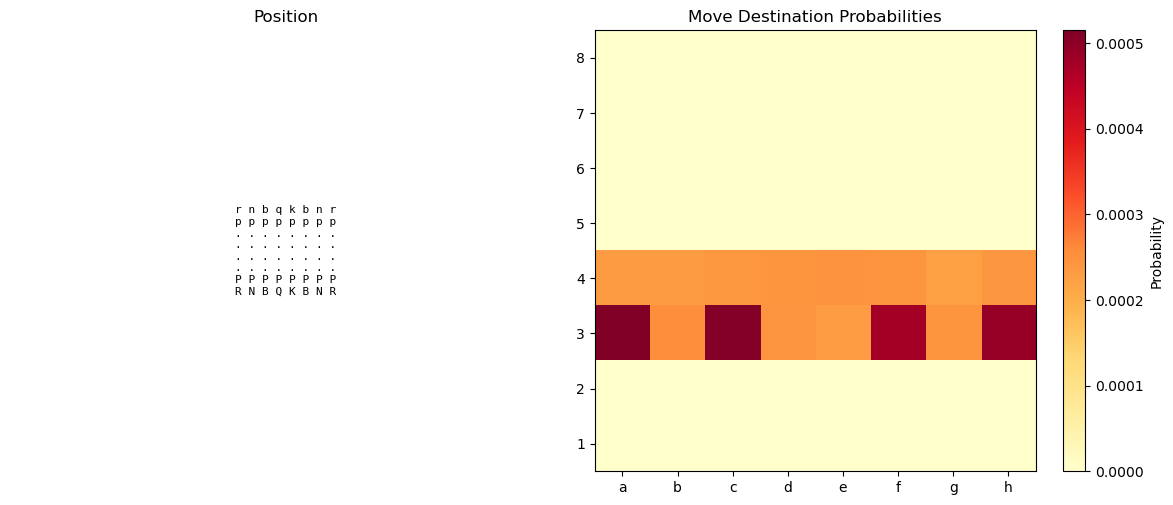

In [97]:
# Visualize move probabilities (if matplotlib available)
if HAS_MATPLOTLIB:
    def visualize_move_probs(fen: str, model: nn.Module, device: str):
        """Visualize move probabilities as a heatmap."""
        board = chess.Board(fen)
        fen_parser = FenParser()
        move_encoder = MoveEncoder()

        # Get predictions
        board_tensor = fen_parser.to_tensor(fen).unsqueeze(0).unsqueeze(0)
        color = torch.tensor([[0 if board.turn else 1]])

        model.eval()
        with torch.no_grad():
            outputs = model(board_tensor.to(device), color.to(device))

        logits = outputs['move_logits'][0].cpu()
        probs = torch.softmax(logits, dim=0)

        # Filter to legal moves
        legal_mask = move_encoder.get_legal_move_mask(board)
        probs[~legal_mask] = 0

        # Create heatmap of "to" squares
        to_heatmap = torch.zeros(8, 8)
        for idx in range(4096):
            if legal_mask[idx]:
                _, to_sq = move_encoder.get_from_to_squares(idx)
                row, col = 7 - (to_sq // 8), to_sq % 8
                to_heatmap[row, col] += probs[idx].item()

        # Plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Board
        ax1.set_title("Position")
        ax1.text(0.5, 0.5, str(board), fontsize=8, family='monospace',
                 ha='center', va='center', transform=ax1.transAxes)
        ax1.axis('off')

        # Heatmap
        im = ax2.imshow(to_heatmap.numpy(), cmap='YlOrRd')
        ax2.set_title("Move Destination Probabilities")
        ax2.set_xticks(range(8))
        ax2.set_yticks(range(8))
        ax2.set_xticklabels(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'])
        ax2.set_yticklabels(['8', '7', '6', '5', '4', '3', '2', '1'])
        plt.colorbar(im, ax=ax2, label='Probability')

        plt.tight_layout()
        plt.show()

    # Visualize for starting position
    visualize_move_probs(
        "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
        resnet_model,
        DEVICE
    )
else:
    print("Skipping visualization - matplotlib not available")

---
# Summary
---

This notebook covered:

1. **Data Encoding**
   - FenParser: FEN ↔ tensor conversion
   - MoveEncoder: UCI ↔ index conversion
   - ScoreEncoder: Perspective-aware score encoding (the critical fix!)

2. **Data Generation**
   - StockfishWrapper: Engine analysis
   - PositionGenerator: Random, opening, endgame positions
   - DataGenerationPipeline: Full labeled dataset generation

3. **Dataset Loading**
   - ChessDataset: PyTorch dataset with caching
   - DataLoaders: Efficient batch loading

4. **Model Architectures**
   - ChessResNet: Fast, AlphaZero-inspired
   - ChessTransformer: Self-attention based
   - ChessHybrid: CNN + attention combination

5. **Loss Functions**
   - Multi-task learning with weighted losses
   - Move, score, capture, outcome prediction

6. **Training**
   - TrainingConfig: All options
   - Trainer: Training loop with callbacks
   - Metrics: Accuracy tracking

7. **Evaluation & Inference**
   - ChessEngine: Model-based play
   - StockfishEvaluator: Elo estimation

## Next Steps

1. Generate a large dataset using `scripts/generate_data.py`
2. Train a model using `scripts/train.py`
3. Evaluate against Stockfish using `scripts/evaluate.py`
4. Play against your model using `scripts/play.py` or `scripts/play_gui.py`